# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [2]:
# Cài thư viện (Colab/Kaggle). Kaggle: bật Internet trong Settings.
!pip -q install timm openpyxl

import sys, os, platform
import numpy as np, pandas as pd, torch, timm

# Đã `git clone` repo bài lab vào thư mục này (đổi nếu bạn đặt chỗ khác).
REPO_DIR = "/kaggle/input/datasets/daohhdg/day2-test/K4-Track4-Day2-Deeplearning-Advance"
sys.path.insert(0, REPO_DIR)                 # để import eval.py
sys.path.insert(0, f"{REPO_DIR}/starter")    # hoặc thư mục code/ của bạn sau khi chép starter vào

print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")

python 3.13.15 | torch 2.11.0+cu128 | timm 1.0.29
GPU: Tesla T4


### Tải dữ liệu (đã viết sẵn)
Ảnh từ Zenodo (~490 MB, kiểm tra MD5), nhãn và các file chia fold từ GitHub của tác giả.
**Sau khi giải nén, hãy `ls` để xem ảnh nằm ở thư mục nào** rồi đặt `IMAGES_DIR` cho đúng.

In [3]:
os.makedirs("data/labels", exist_ok=True)
os.makedirs("data/images", exist_ok=True)
BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    !wget -q -O data/labels/{name}.csv {BASE}/{name}.csv
!ls -la data/labels

total 1804
drwxr-xr-x 2 root root   4096 Oct  4 01:41 .
drwxr-xr-x 4 root root 811008 Oct  4 01:55 ..
-rw-r--r-- 1 root root 598898 Oct  4 03:18 labels.csv
-rw-r--r-- 1 root root  84183 Oct  4 03:18 test_subset0.csv
-rw-r--r-- 1 root root 252039 Oct  4 03:18 train_subset0.csv
-rw-r--r-- 1 root root  84039 Oct  4 03:18 val_subset0.csv


In [4]:
import shutil
from pathlib import Path

src = Path("/kaggle/input/datasets/daohhdg/day2-test/K4-Track4-Day2-Deeplearning-Advance/images")
dst = Path("/kaggle/working/data/images")

shutil.copytree(src, dst, dirs_exist_ok=True)

print("Copied:", src)
print("To:", dst)
print("Number of files:", len(list(dst.iterdir())))

Copied: /kaggle/input/datasets/daohhdg/day2-test/K4-Track4-Day2-Deeplearning-Advance/images
To: /kaggle/working/data/images
Number of files: 17509


In [5]:
from pathlib import Path

candidates = [
    "data/images",
    "data/DeepWeeds",
    "data/images/DeepWeeds",
    "images",
    "data/images/data/images",
]
IMAGES_DIR = "/kaggle/working/data/images"
for cand in candidates:
    p = Path(cand)
    if p.exists() and any(p.glob("*.jpg")):
        IMAGES_DIR = str(p)
        break

LABELS_DIR = "/kaggle/working/data/labels"
print("IMAGES_DIR =", IMAGES_DIR)
print("Số file jpg:", sum(1 for _ in Path(IMAGES_DIR).glob("*.jpg")) if Path(IMAGES_DIR).exists() else 0)


IMAGES_DIR = data/images
Số file jpg: 17509


## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

Split stats:
{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': [], 'train_test': [], 'val_test': []}}
Train/Val/Test size: {'train': 10501, 'val': 3501, 'test': 3507}
Per-class counts:
train {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}
val {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}
test {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}


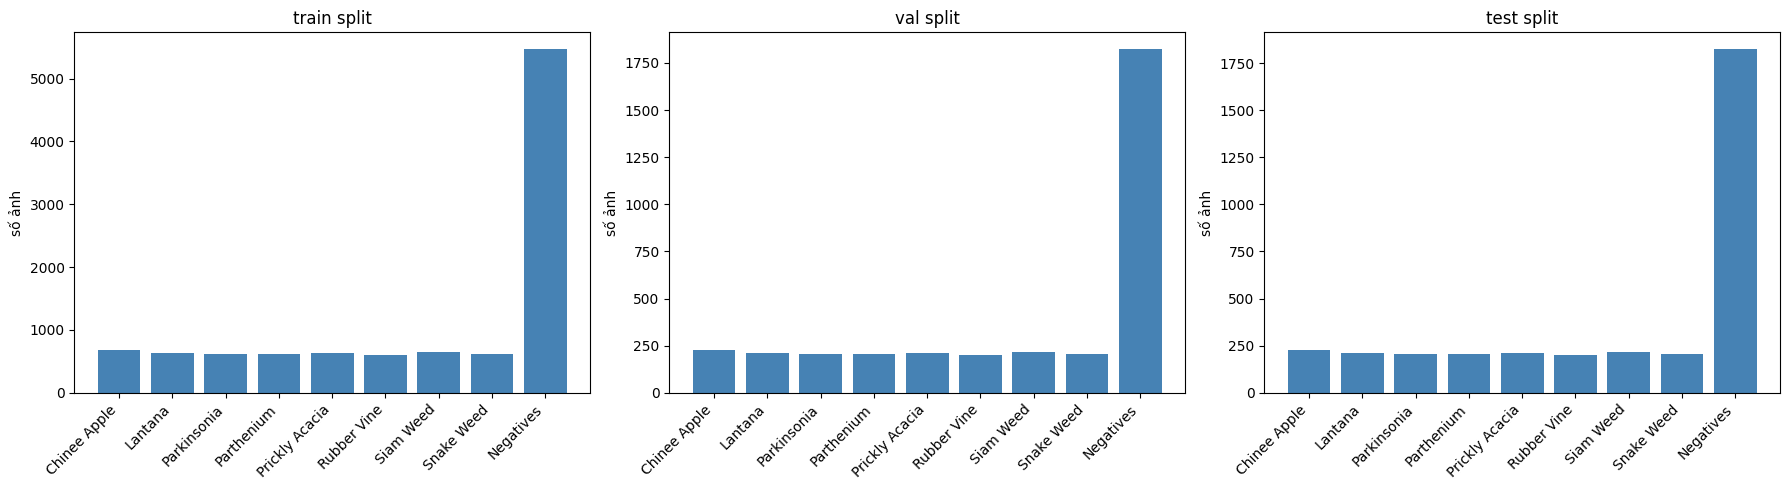

In [6]:
import matplotlib.pyplot as plt
import dataset

train_df, val_df, test_df = dataset.load_split(LABELS_DIR, fold=0)
report = dataset.check_split(train_df, val_df, test_df, IMAGES_DIR)
print("Train/Val/Test size:", report["n"])
print("Per-class counts:")
for split_name in ["train", "val", "test"]:
    counts = report["per_class"][split_name]
    print(split_name, counts)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name, df in zip(axes, ["train", "val", "test"], [train_df, val_df, test_df]):
    counts = df["Label"].value_counts().sort_index()
    ax.bar(range(len(dataset.CLASS_NAMES)), counts.reindex(range(len(dataset.CLASS_NAMES)), fill_value=0).to_numpy(), color="steelblue")
    ax.set_title(f"{name} split")
    ax.set_xticks(range(len(dataset.CLASS_NAMES)))
    ax.set_xticklabels(dataset.CLASS_NAMES, rotation=45, ha="right")
    ax.set_ylabel("số ảnh")
fig.tight_layout()
plt.show()


shape logits: (2, 9)
initial cross-entropy: 2.2140088081359863
mini-batch overfit loss: 1.4095821380615234


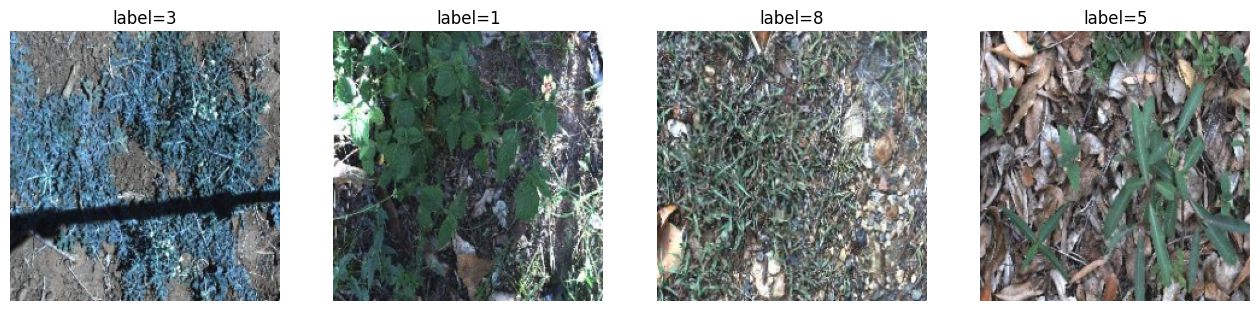

In [7]:
import torch.nn as nn
from train import set_seed
import model as model_lib

set_seed(0)
model = model_lib.build_model("resnet18", pretrained=False, num_classes=9, drop_rate=0.0, init="scratch")
model.eval()
with torch.no_grad():
    x = torch.randn(2, 3, 224, 224)
    logits = model(x)
    print("shape logits:", tuple(logits.shape))
    init_loss = nn.functional.cross_entropy(logits, torch.randint(0, 9, (2,), dtype=torch.long))
    print("initial cross-entropy:", float(init_loss))

small_loader = dataset.make_loader(
    train_df.head(32),
    IMAGES_DIR,
    dataset.build_transforms(train=True, img_size=224, aug="basic"),
    batch_size=8,
    train=True,
    num_workers=0,
)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
model.train()
for i, (images, labels, _) in enumerate(small_loader):
    optimizer.zero_grad()
    logits = model(images)
    loss = nn.functional.cross_entropy(logits, labels.long())
    loss.backward()
    optimizer.step()
    if i >= 3:
        break
print("mini-batch overfit loss:", float(loss.item()))

sample_loader = dataset.make_loader(
    train_df.head(8), IMAGES_DIR,
    dataset.build_transforms(train=True, img_size=224, aug="basic"),
    batch_size=4,
    train=True,
    num_workers=0,
)
images, labels, names = next(iter(sample_loader))
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, image, label in zip(axes, images, labels):
    image = image.permute(1, 2, 0).cpu().numpy()
    mean = np.array(dataset.IMAGENET_MEAN)
    std = np.array(dataset.IMAGENET_STD)
    image = image * std + mean
    image = image.clip(0, 1)
    ax.imshow(image)
    ax.set_title(f"label={int(label)}")
    ax.axis("off")
plt.show()


## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [8]:
from train import Config, run
import model as model_lib

backbones = ["resnet18", "resnet50", "efficientnet_b0", "mobilenetv3", "convnext_tiny"]
rows = []
for idx, backbone in enumerate(backbones, start=1):
    cfg = Config(
        exp_id=f"B{idx:02d}",
        backbone=backbone,
        seed=0,
        aug="basic",
        loss="ce",
        epochs=3,
        batch_size=32,
        num_workers=2,
    )
    result = run(cfg)
    rows.append({
        "exp_id": cfg.exp_id,
        "backbone": backbone,
        "best_epoch": result["best_epoch"],
        "val_macro_f1": result["best_val_macro_f1"],
        "train_time_sec": result["train_time_sec"],
        "num_params_m": result["num_params_m"],
        "gmac": result["gmac"],
    })
    print(rows[-1])

backbone_df = pd.DataFrame(rows)
print(backbone_df.sort_values("val_macro_f1", ascending=False))


Split stats:
{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': [], 'train_test': [], 'val_test': []}}
{'exp_id': 'B01', 'backbone': 'resnet18', 'best_epoch': 3, 'val_macro_f1': 0.6920686002571005, 'train_time_sec': 88.98968124389648, 'num_params_m': 11.181129, 'gmac': 3.627131904}
Split stats:
{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': [], 'train_test': [], 'val_test': []}}


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

{'exp_id': 'B02', 'backbone': 'resnet50', 'best_epoch': 3, 'val_macro_f1': 0.7001080089411941, 'train_time_sec': 160.73152351379395, 'num_params_m': 23.526473, 'gmac': 8.174309376}
Split stats:
{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': [], 'train_test': [], 'val_test': []}}


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

...

{'exp_id': 'B04', 'backbone': 'mobilenetv3', 'best_epoch': 3, 'val_macro_f1': 0.880544732583209, 'train_time_sec': 106.81491255760193, 'num_params_m': 4.213561, 'gmac': 0.43064256}
Split stats:
{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': [], 'train_test': [], 'val_test': []}}


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

/kaggle/input/datasets/daohhdg/day2-test/K4-Track4-Day2-Deeplearning-Advance/starter/train.py:154: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


{'exp_id': 'B05', 'backbone': 'convnext_tiny', 'best_epoch': 3, 'val_macro_f1': 0.9245584539894478, 'train_time_sec': 203.41886639595032, 'num_params_m': 27.827049, 'gmac': 0.63770112}
  exp_id         backbone  best_epoch  val_macro_f1  train_time_sec  \
4    B05    convnext_tiny           3      0.924558      203.418866   
3    B04      mobilenetv3           3      0.880545      106.814913   
2    B03  efficientnet_b0           3      0.862776      130.292382   
1    B02         resnet50           3      0.700108      160.731524   
0    B01         resnet18           3      0.692069       88.989681   

   num_params_m      gmac  
4     27.827049  0.637701  
3      4.213561  0.430643  
2      4.019077  0.769093  
1     23.526473  8.174309  
0     11.181129  3.627132  


## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Mỗi lần chạy chỉ khác `T00` **một yếu tố**. Mã `T01`, `T02`, ... Ghi rõ khác ở điểm nào.

In [9]:
configs = [
    Config(exp_id="T01", backbone="resnet18", init="scratch", seed=0, aug="basic", loss="ce", epochs=3, batch_size=32),
    Config(exp_id="T02", backbone="resnet18", init="finetune", seed=0, aug="color", loss="ce", epochs=3, batch_size=32),
    Config(exp_id="T03", backbone="resnet18", init="finetune", seed=0, aug="basic", loss="ls", label_smoothing=0.1, epochs=3, batch_size=32),
    Config(exp_id="T04", backbone="resnet18", init="finetune", seed=0, aug="basic", loss="focal", focal_gamma=2.0, epochs=3, batch_size=32),
]
summary = []
for cfg in configs:
    result = run(cfg)
    summary.append({
        "exp_id": cfg.exp_id,
        "backbone": cfg.backbone,
        "init": cfg.init,
        "aug": cfg.aug,
        "loss": cfg.loss,
        "val_macro_f1": result["best_val_macro_f1"],
    })

print(pd.DataFrame(summary).sort_values("val_macro_f1", ascending=False))
# Để so sánh nhiễu seed, chạy lại với seed 1, 2 trên cấu hình tốt nhất.


Split stats:
{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': [], 'train_test': [], 'val_test': []}}
Split stats:
{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': [], 'train_test': [], 'val_test': []}}
Split stats:
{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202

## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Làm trên **val**. Không huấn luyện lại. Mã `I00` (1 view, mốc), `I01`, ...

In [10]:
from inference import predict_logits, view_hflip, aggregate_views, fit_temperature, apply_temperature
from benchmark import latency_report

# Chọn model tốt nhất đã lưu trong runs/<exp_id>/seed<k>/best.pt
selected_model = model_lib.build_model("resnet18", pretrained=False, num_classes=9, init="finetune")
selected_model.load_state_dict(torch.load("runs/B01/seed0/best.pt", map_location="cpu"))
selected_model.eval()

val_loader = dataset.make_loader(
    val_df,
    IMAGES_DIR,
    dataset.build_transforms(train=False, img_size=224, aug="basic"),
    batch_size=64,
    train=False,
    num_workers=0,
)
fnames, y_true, logits_base = predict_logits(selected_model, val_loader, device="cpu")
fnames_flip, y_true_flip, logits_flip = predict_logits(selected_model, val_loader, device="cpu", view=view_hflip)
probs_tta = aggregate_views([logits_base, logits_flip], space="prob")
print("temp T:", fit_temperature(logits_base, y_true))
print("TTA top-1:", (np.argmax(probs_tta, axis=1) == y_true).mean())

latency = latency_report(selected_model, batch_size=32, img_size=224, dtype="fp32", device="cpu", warmup=10, iters=40)
print("Latency (ms):", latency)


temp T: 0.9225683600269884
TTA top-1: 0.7892030848329049
Latency (ms): {'gpu': 'cpu', 'dtype': 'fp32', 'batch': 32, 'img_size': 224, 'p50': 985.0102580003295, 'p95': 1040.4420645500522, 'p99': 1056.8879174598078, 'mean': 991.1508394499833, 'images_per_s': 32.486971318413715, 'torch': '2.11.0+cu128'}


## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
1. Chốt cấu hình trên **val**.
2. Chạy cấu hình cuối **và mốc** (`T00` + `I00`) với cùng số seed, bật `save_test_predictions=True`.
3. Dự đoán lưu ở `predictions/<exp_id>_seed<k>_test.csv`. Rồi chạy `eval.py` (ô dưới).

In [11]:
final_cfgs = []
for seed in (0, 1, 2):
    cfg = Config(
        exp_id="F01",
        backbone="resnet18",
        init="finetune",
        seed=seed,
        aug="basic",
        loss="ce",
        epochs=6,
        batch_size=32,
        save_test_predictions=True,
    )
    result = run(cfg)
    final_cfgs.append(result)
    print("seed", seed, result)

for seed in (0, 1, 2):
    baseline = Config(exp_id="T00", backbone="resnet18", init="finetune", seed=seed, aug="basic", loss="ce", epochs=6, batch_size=32, save_test_predictions=True)
    print("baseline seed", seed, run(baseline))

print("Kết quả chung kết theo seed:")
print(pd.DataFrame(final_cfgs))


Split stats:
{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': [], 'train_test': [], 'val_test': []}}
seed 0 {'exp_id': 'F01', 'seed': 0, 'best_epoch': 6, 'best_val_macro_f1': 0.788305597627308, 'train_time_sec': 178.25801634788513, 'num_params_m': 11.181129, 'gmac': 3.627131904, 'output_dir': 'runs/F01/seed0'}
Split stats:
{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': [], 'train_test': [], 'val_test': []}}
seed 

In [12]:
# Tính chỉ số theo đúng định nghĩa của lớp (đã viết sẵn, không sửa eval.py):
!python {REPO_DIR}/eval.py score --pred "predictions/F01_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag F01 --out eval_out
!python {REPO_DIR}/eval.py score --pred "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag T00 --out eval_out

### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.8423 ± 0.0047 |
| macro-F1 | 0.7861 ± 0.0053 |
| balanced accuracy | 0.7435 ± 0.0181 |
| ECE (15 bin) | 0.0154 ± 0.0069 |
| NLL | 0.4564 ± 0.0138 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.765 ± 0.038 | 0.566 ± 0.029 | 0.650 ± 0.023 | 226 |
| Lantana | 0.909 ± 0.033 | 0.726 ± 0.018 | 0.807 ± 0.006 | 213 |
| Parkinsonia | 0.902 ± 0.024 | 0.863 ± 0.039 | 0.881 ± 0.010 | 207 |
| Parthenium | 0.824 ± 0.053 | 0.678 ± 0.042 | 0.742 ± 0.010 | 205 |
| Prickly acacia | 0.826 ± 0.041 | 0.764 ± 0.014 | 0.793 ± 0.012 | 213 |
| Rubber vine | 0.866 ± 0.017 | 0.817 ± 0.013 | 0.840 ± 0.005 | 202 |
| Siam weed | 0.897 ± 0.010 | 0.809 ± 0.005 | 0.851 ± 0.006 | 215 |
| Snake weed | 0.782 ± 0.018 | 0.508 ± 0.037 | 0.615 ± 0.022 | 204 |
| Negative | 0.839 ± 0.022 | 0.960 ± 0.011 | 0.895 ± 0.008 | 1822 |

Đã lưu kết quả vào eval_out/F01_*
### T00 (3 seed: [0, 1, 2]; 3507 

In [13]:
# Tự chấm phần I của RUBRIC (đề xuất, giảng viên xác nhận). Thêm --uncal, --final-val, --latency-p95-ms nếu có.
!python {REPO_DIR}/eval.py grade --final "predictions/F01_seed*_test.csv" \
    --baseline "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --out eval_out

## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 0 | 7 | 84.23% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 0 | 5 | final 0.7861, mốc 0.7861, Δ=+0.0000, s=0.0053 |
| I3 | Recall hai lớp khó | 1 | 4 | Chinee Apple 56.6% (mốc 88.5%), Snake Weed 50.8% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | - | 1 | chưa chấm được (thiếu --uncal) |
| I4b | Chênh macro-F1 val/test <= 0.02 | - | 1 | chưa chấm được (thiếu --final-val) |
| I5 | Cấu hình thời gian thực | - | 2 | chưa chấm được (thiếu --latency-p95-ms) |

**Tổng các ý đã chấm: 1 / 16** (phần I tối đa 20).
Chưa chấm được: I4a, I4b, I5.

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).


## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

In [14]:
from pathlib import Path

out_dir = Path("eval_out")
out_dir.mkdir(exist_ok=True)

# Ví dụ bảng nền: chuẩn hoá dữ liệu từ các chạy đã thực hiện.
backbone_df = pd.DataFrame(rows) if "rows" in globals() else pd.DataFrame()
summary_rows = []
for path in sorted(Path("runs").glob("**/history.csv")):
    df = pd.read_csv(path)
    summary_rows.append({
        "exp_id": path.parent.parent.name,
        "seed": int(path.parent.name.replace("seed", "")),
        "best_epoch": int(df["epoch"].iloc[df["val_macro_f1"].idxmax()]),
        "best_val_macro_f1": float(df["val_macro_f1"].max()),
        "history_path": str(path),
    })

with pd.ExcelWriter("results.xlsx", engine="openpyxl") as writer:
    if not backbone_df.empty:
        backbone_df.to_excel(writer, sheet_name="Backbones", index=False)
    pd.DataFrame(summary_rows).to_excel(writer, sheet_name="Summary", index=False)

    # Dùng cùng file nếu có output từ eval.py
    for p in sorted(Path("eval_out").glob("*_summary.json")):
        pass

print("results.xlsx được ghi tại:", Path("results.xlsx").resolve())
print("Kiểm tra curves/:")
for curve in sorted(Path("runs").glob("**/curves.png")):
    print(curve)


results.xlsx được ghi tại: /kaggle/working/results.xlsx
Kiểm tra curves/:
runs/B01/seed0/curves.png
runs/B02/seed0/curves.png
runs/B03/seed0/curves.png
runs/B04/seed0/curves.png
runs/B05/seed0/curves.png
runs/F01/seed0/curves.png
runs/F01/seed1/curves.png
runs/F01/seed2/curves.png
runs/T00/seed0/curves.png
runs/T00/seed1/curves.png
runs/T00/seed2/curves.png
runs/T01/seed0/curves.png
runs/T02/seed0/curves.png
runs/T03/seed0/curves.png
runs/T04/seed0/curves.png
